# DS605 Lab 6 (Notebook 1 of 2): Image Feature Extraction and Classification

**Dataset:** Asphalt Crack Dataset, 400 images (Mendeley Data)
**Covers:** Part A (image features and classification) and the image half of Part C (representation improvement)
**Constraint:** No CNNs, deep-learning models or pretrained embeddings. Every feature is computed from raw pixels with NumPy and OpenCV. Scikit-learn is used only for traditional classifiers.

**Workflow**

```
Raw image -> Preprocessing -> Feature extraction -> Train-test split -> ML model -> Evaluation -> Representation improvement
```

**Expected folder layout**

```
data/asphalt_images/<crack folder>/*.jpg
data/asphalt_images/<non-crack folder>/*.jpg
```

Labels are inferred from folder or file names containing "crack" and "non-crack" (or "no crack", "negative"). If your folders are named differently, adjust `infer_label` in section A1. Outputs are written to `results/`.

**Companion notebook:** `202618052_Lab_6_Text_Vectorization_and_Spam_Classification.ipynb` (Part B and the text half of Part C).

## Concept and intuition

### Why feature extraction is necessary
Classical models such as logistic regression, SVM and random forests need a fixed-length numeric vector for every sample. A raw image is a grid of pixels, and using every pixel directly gives tens of thousands of highly correlated inputs. Hand-crafted features compress each image into a short, interpretable row that captures what matters for the task. The representation usually matters more than the choice of classifier, which is the point of Part C.

### Preprocessing choices
* **Inspecting shape and channels** reveals whether images are colour or grayscale and whether their sizes differ.
* **Resizing to a common size** is required because count-based features (for example the number of edge pixels) scale with image area. Without it, two identical surfaces at different resolutions would look different. `INTER_AREA` is used because it is the appropriate interpolation when shrinking.
* **Grayscale conversion** is used because a crack is defined by intensity contrast (a dark line on lighter asphalt), not by colour. It also reduces three channels to one.

### Intensity features (NumPy)
| Feature | Intuition |
|---|---|
| Mean brightness | Overall lightness of the surface. |
| Contrast (standard deviation) | A crack adds a dark line against a lighter background, which increases spread. |
| Dark and bright pixel ratios | Directly measure the share of shadow-like or crack-like pixels. |
| Percentiles, min, max, median | Describe the histogram shape and are robust to outliers. |
| Skewness and kurtosis | A crack creates a heavy dark tail, which changes the distribution shape. |
| Entropy | Measures how much texture and variation the image contains. |

### Canny edge features (OpenCV)
Canny finds places where intensity changes sharply, which is exactly what the boundary of a crack is. It works in four stages: Gaussian smoothing, gradient computation, non-maximum suppression (thinning edges to one pixel) and hysteresis thresholding (a weak edge is kept only if it connects to a strong one). Edge count and edge density (edges divided by area) summarise how much structure an image contains. A cracked surface is expected to have more edges than smooth asphalt.

### Why these classifiers
* **Logistic Regression:** a linear baseline that shows whether the features are linearly separable.
* **SVM (RBF):** handles non-linear boundaries on small, low-dimensional data.
* **k-NN:** a distance-based method that shows whether similar images cluster together, and demonstrates why scaling matters.
* **Random Forest and Gradient Boosting:** tree ensembles that need no scaling, capture feature interactions and give feature importances.

Scale-sensitive models are wrapped in a pipeline with `StandardScaler`, so scaling is learned from the training data only. With only 400 images a single split is noisy, so 5-fold cross-validated F1 is reported in addition.

### Evaluation metrics
Accuracy alone can hide problems. **Recall** is arguably the most important metric here, because a missed crack is a safety and maintenance risk. **Precision** measures false alarms, **F1** balances the two, and the **confusion matrix** shows exactly which errors occur. Training and prediction times quantify computational cost.

## 0. Setup and configuration

In [1]:
import os
import re
import time
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

# ---- Paths (edit these, or set environment variables) ----
IMAGE_DIR = Path(os.environ.get("IMAGE_DIR", "data/asphalt_images"))
TEXT_CSV = Path(os.environ.get("TEXT_CSV", "data/emails.csv"))
OUT_DIR = Path(os.environ.get("OUT_DIR", "results"))

# ---- Experiment settings ----
IMG_SIZE = (256, 256)      # (width, height) common size for all images
TEST_SIZE = 0.20
RANDOM_STATE = 42
DARK_T, BRIGHT_T = 60, 190  # thresholds for dark / bright pixel ratios
CANNY_LO, CANNY_HI = 50, 150  # baseline Canny thresholds

OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "figures").mkdir(exist_ok=True)


def save_fig(fig, name):
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figures" / name, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def metrics_row(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def timed_fit_predict(model, X_tr, y_tr, X_te):
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0
    t0 = time.perf_counter()
    pred = model.predict(X_te)
    predict_time = time.perf_counter() - t0
    return pred, train_time, predict_time


def plot_confusion_matrices(items, class_names, filename, ncols=3):
    """items: list of (title, 2x2 confusion matrix)."""
    nrows = int(np.ceil(len(items) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax, (title, cm) in zip(axes, items):
        ax.imshow(cm, cmap="Blues")
        ax.set_title(title, fontsize=9)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(class_names); ax.set_yticklabels(class_names)
        ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i, j], ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2 else "black")
    for ax in axes[len(items):]:
        ax.axis("off")
    save_fig(fig, filename)

# Part A: Image feature extraction and classification

## A1. Read images, inspect dimensions and channels, resize, convert to grayscale

In [2]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def infer_label(path):
    """Infer the label from folder / file names. 1 = crack, 0 = non-crack."""
    rel = path.relative_to(IMAGE_DIR)
    text = " ".join([p.lower() for p in rel.parts[:-1]] + [path.stem.lower()])
    if re.search(r"non[\s_\-]?crack|no[\s_\-]?crack|negative|without|uncracked|intact", text):
        return 0
    if "crack" in text or "positive" in text:
        return 1
    return None


if not IMAGE_DIR.exists():
    raise FileNotFoundError(f"Image folder not found: {IMAGE_DIR.resolve()}. Run the notebook from the folder that contains 'data/'.")

records, gray_images, paths = [], [], []
for p in sorted(IMAGE_DIR.rglob("*")):
    if p.suffix.lower() not in IMG_EXT:
        continue
    label = infer_label(p)
    try:
        raw = cv2.imdecode(np.fromfile(str(p), dtype=np.uint8), cv2.IMREAD_UNCHANGED)
    except Exception:
        raw = None
    if raw is None or label is None:
        print(f"Skipping (unreadable or unlabeled): {p}")
        continue
    if raw.dtype == np.uint16:
        raw = (raw / 257).astype(np.uint8)
    channels = 1 if raw.ndim == 2 else raw.shape[2]
    if channels == 4:
        raw = cv2.cvtColor(raw, cv2.COLOR_BGRA2BGR)
    gray = raw if raw.ndim == 2 else cv2.cvtColor(raw, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, IMG_SIZE, interpolation=cv2.INTER_AREA)
    records.append({"path": str(p), "orig_height": raw.shape[0], "orig_width": raw.shape[1],
                    "channels": channels, "dtype": str(raw.dtype), "label": label})
    gray_images.append(gray)
    paths.append(p)

if not records:
    raise RuntimeError(f"No labelled images found under {IMAGE_DIR.resolve()}.")
meta = pd.DataFrame(records)
gray_images = np.stack(gray_images)
y_img = meta["label"].values
assert len(np.unique(y_img)) == 2, "Both classes (crack / non-crack) must be found. Check folder names."

print(f"Images loaded: {len(meta)}")
print("\nClass distribution (1 = crack, 0 = non-crack):")
print(meta["label"].value_counts().rename({1: "crack", 0: "non-crack"}))
print("\nOriginal shapes (height, width, channels):")
print(meta.groupby(["orig_height", "orig_width", "channels"]).size().rename("count"))
print(f"\nAll images resized to {IMG_SIZE[0]}x{IMG_SIZE[1]} and converted to grayscale: {gray_images.shape}")
meta.to_csv(OUT_DIR / "image_metadata.csv", index=False)

Images loaded: 400

Class distribution (1 = crack, 0 = non-crack):
label
crack        200
non-crack    200
Name: count, dtype: int64

Original shapes (height, width, channels):
orig_height  orig_width  channels
448          448         3           400
Name: count, dtype: int64

All images resized to 256x256 and converted to grayscale: (400, 256, 256)


## A2. Sample images

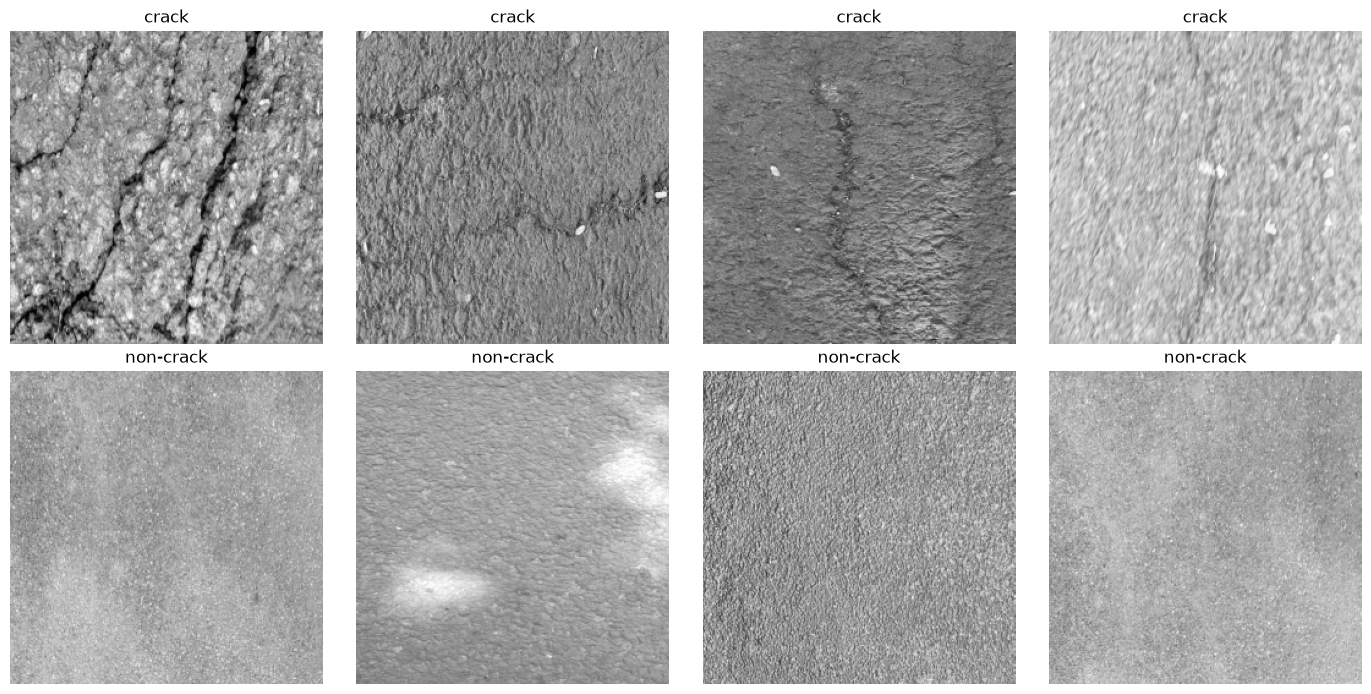

In [3]:
CLASS_NAMES_IMG = ["non-crack", "crack"]
rng = np.random.RandomState(RANDOM_STATE)
pick = {c: rng.choice(np.where(y_img == c)[0], size=min(4, (y_img == c).sum()), replace=False)
        for c in (1, 0)}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for r, c in enumerate((1, 0)):
    for k, idx in enumerate(pick[c]):
        axes[r, k].imshow(gray_images[idx], cmap="gray", vmin=0, vmax=255)
        axes[r, k].set_title(CLASS_NAMES_IMG[c]); axes[r, k].axis("off")
save_fig(fig, "sample_images.png")

## A3. Baseline features: intensity statistics (NumPy) and Canny edges (OpenCV)

Every quantity below is computed directly from the pixel array.

In [4]:
def intensity_features(gray):
    g = gray.astype(np.float32)
    mean, std = g.mean(), g.std()
    z = (g - mean) / (std + 1e-8)
    hist = np.bincount(gray.ravel(), minlength=256) / gray.size
    nz = hist[hist > 0]
    p05, p25, med, p75, p95 = np.percentile(g, [5, 25, 50, 75, 95])
    return {
        "mean_brightness": mean,
        "contrast_std": std,
        "min_intensity": g.min(),
        "max_intensity": g.max(),
        "median_intensity": med,
        "p05": p05, "p25": p25, "p75": p75, "p95": p95,
        "skewness": (z ** 3).mean(),
        "kurtosis": (z ** 4).mean() - 3.0,
        "dark_pixel_ratio": (g < DARK_T).mean(),
        "bright_pixel_ratio": (g > BRIGHT_T).mean(),
        "entropy": float(-(nz * np.log2(nz)).sum()),
        "michelson_contrast": (g.max() - g.min()) / (g.max() + g.min() + 1e-8),
    }


def baseline_features(gray):
    feats = intensity_features(gray)
    edges = cv2.Canny(gray, CANNY_LO, CANNY_HI)
    feats["canny_edge_count"] = int((edges > 0).sum())
    feats["canny_edge_density"] = float((edges > 0).mean())
    return feats


t0 = time.perf_counter()
X_base_df = pd.DataFrame([baseline_features(g) for g in gray_images])
t_extract_base = time.perf_counter() - t0
print(f"Baseline: {X_base_df.shape[1]} features, extraction time {t_extract_base:.2f}s")

feature_table = X_base_df.copy()
feature_table.insert(0, "image", [p.name for p in paths])
feature_table["label"] = y_img
feature_table.to_csv(OUT_DIR / "image_features_baseline.csv", index=False)
feature_table.head()

Baseline: 17 features, extraction time 2.49s


,image,mean_brightness,contrast_std,min_intensity,max_intensity,median_intensity,p05,p25,p75,p95,skewness,kurtosis,dark_pixel_ratio,bright_pixel_ratio,entropy,michelson_contrast,canny_edge_count,canny_edge_density,label
0,IMG_20180513_164959951_HDR resized_448.jpg,122.096420,30.724438,23.0,246.0,120.0,74.0,101.0,141.0,177.0,0.308248,-0.006832,0.011032,0.019928,6.971744,0.828996,24318,0.371063,1
1,IMG_20180513_165129852_HDR resized_448.jpg,131.822876,23.531446,2.0,245.0,133.0,91.0,118.0,147.0,168.0,-0.301053,1.088840,0.005493,0.008423,6.570038,0.983806,23694,0.361542,1
2,IMG_20180513_165150613_HDR resized_448.jpg,121.171051,29.188046,3.0,242.0,120.0,74.0,105.0,136.0,174.0,0.091327,0.893518,0.022766,0.016830,6.861114,0.975510,22965,0.350418,1
3,IMG_20180513_165345878_HDR resized_448.jpg,130.117706,24.922821,19.0,253.0,131.0,88.0,114.0,147.0,169.0,-0.091696,0.492313,0.003998,0.007553,6.673819,0.860294,24543,0.374496,1
4,IMG_20180513_165349788_HDR resized_448.jpg,131.080307,25.471376,14.0,253.0,132.0,88.0,115.0,147.0,170.0,-0.043432,0.895450,0.005112,0.010757,6.697336,0.895131,24150,0.368500,1


## A4. Canny edge visualisation

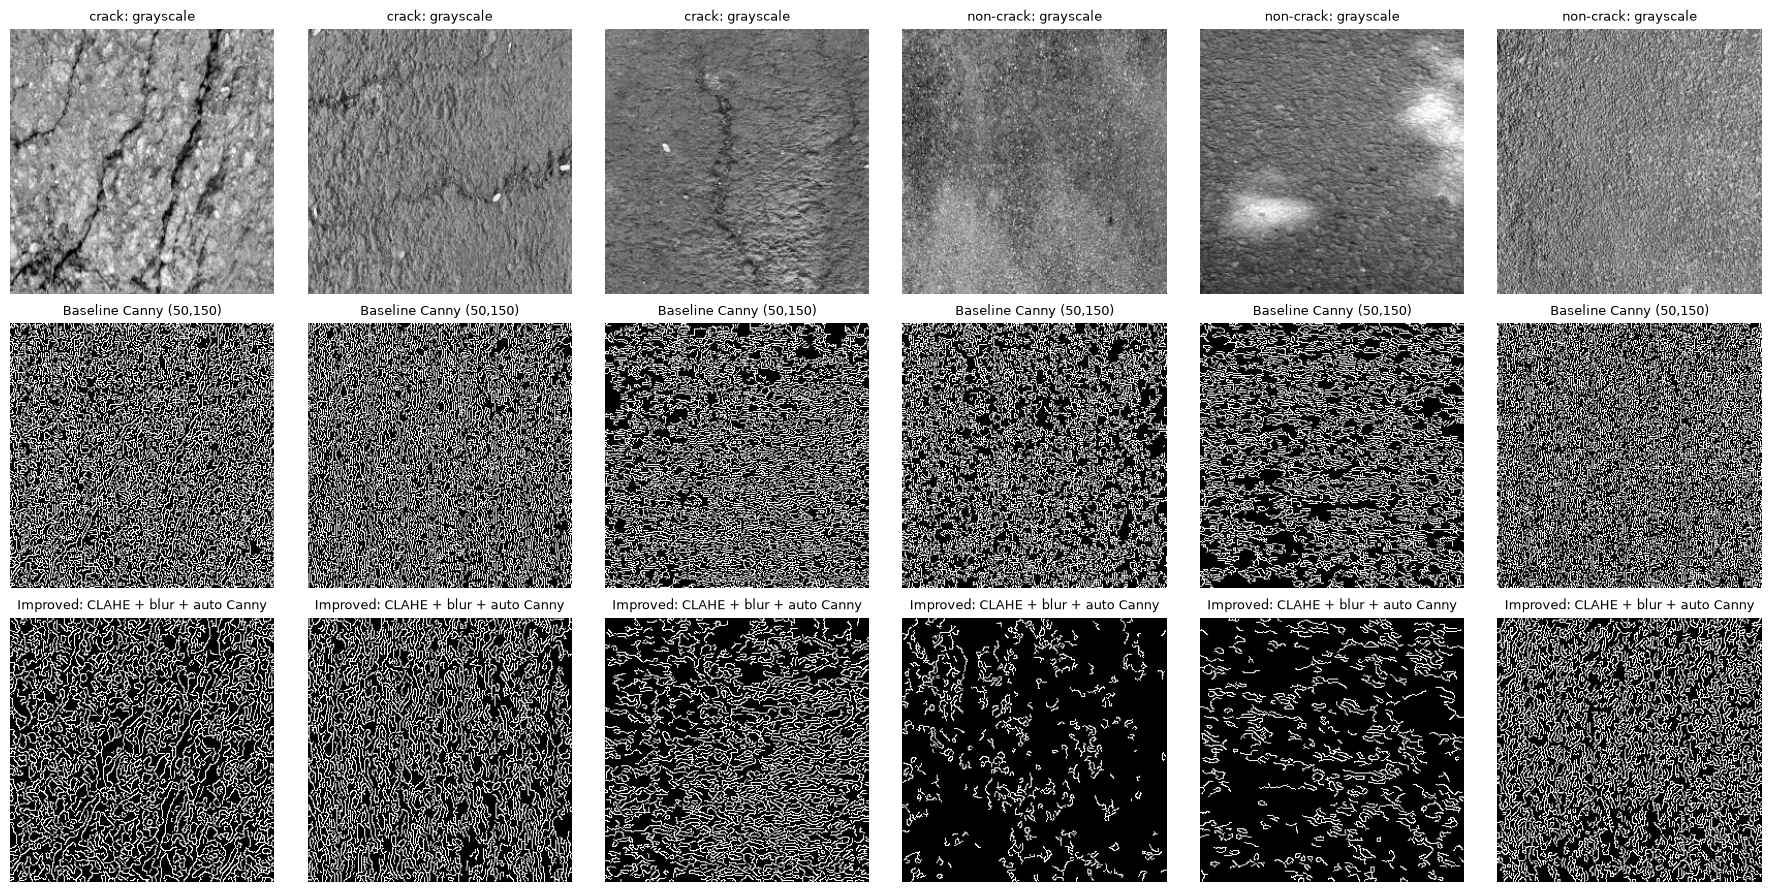

In [5]:
def clahe_blur(gray):
    eq = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
    return cv2.GaussianBlur(eq, (5, 5), 0)


def auto_canny(img, sigma=0.33):
    """Canny thresholds derived from the median intensity of the image."""
    med = float(np.median(img))
    lo, hi = int(max(0, (1 - sigma) * med)), int(min(255, (1 + sigma) * med))
    return cv2.Canny(img, lo, hi)


show = list(pick[1][:3]) + list(pick[0][:3])
fig, axes = plt.subplots(3, len(show), figsize=(3 * len(show), 9))
for k, idx in enumerate(show):
    g = gray_images[idx]
    axes[0, k].imshow(g, cmap="gray"); axes[0, k].set_title(f"{CLASS_NAMES_IMG[y_img[idx]]}: grayscale", fontsize=9)
    axes[1, k].imshow(cv2.Canny(g, CANNY_LO, CANNY_HI), cmap="gray")
    axes[1, k].set_title(f"Baseline Canny ({CANNY_LO},{CANNY_HI})", fontsize=9)
    axes[2, k].imshow(auto_canny(clahe_blur(g)), cmap="gray")
    axes[2, k].set_title("Improved: CLAHE + blur + auto Canny", fontsize=9)
    for r in range(3):
        axes[r, k].axis("off")
save_fig(fig, "canny_edge_visualization.png")

## A5. Train-test split and baseline classifiers

A single stratified split is created once and reused for every experiment so that all
comparisons (baseline vs improved) are made on identical train and test images.

In [6]:
idx_tr, idx_te = train_test_split(np.arange(len(y_img)), test_size=TEST_SIZE,
                                  stratify=y_img, random_state=RANDOM_STATE)
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def image_models():
    return {
        "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
        "SVM (RBF)": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale")),
        "k-NN (k=5)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
        "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    }


def run_image_experiment(X_df, label, extract_time):
    X, rows, cms = X_df.values, [], {}
    for name, model in image_models().items():
        pred, tt, tp = timed_fit_predict(model, X[idx_tr], y_img[idx_tr], X[idx_te])
        cv_f1 = cross_val_score(clone(model), X, y_img, cv=CV, scoring="f1")
        rows.append({"feature_set": label, "n_features": X.shape[1], "model": name,
                     **metrics_row(y_img[idx_te], pred),
                     "cv_f1_mean": cv_f1.mean(), "cv_f1_std": cv_f1.std(),
                     "train_time_s": tt, "predict_time_s": tp,
                     "feature_extraction_time_s": extract_time})
        cms[(label, name)] = confusion_matrix(y_img[idx_te], pred)
    return pd.DataFrame(rows), cms


res_base, cms_base = run_image_experiment(X_base_df, "Baseline", t_extract_base)
print(res_base.drop(columns=["feature_set"]).round(4).to_string(index=False))

 n_features               model  accuracy  precision  recall     f1  cv_f1_mean  cv_f1_std  train_time_s  predict_time_s  feature_extraction_time_s
         17 Logistic Regression    0.9125     0.9024   0.925 0.9136      0.9092     0.0243        0.0272          0.0013                      2.494
         17           SVM (RBF)    0.9500     0.9286   0.975 0.9512      0.9519     0.0221        0.0070          0.0018                      2.494
         17          k-NN (k=5)    0.9625     0.9512   0.975 0.9630      0.9514     0.0195        0.0014          3.4819                      2.494
         17       Random Forest    0.9500     0.9500   0.950 0.9500      0.9403     0.0203        0.5500          0.0603                      2.494
         17   Gradient Boosting    0.9375     0.9487   0.925 0.9367      0.9501     0.0235        0.3128          0.0005                      2.494


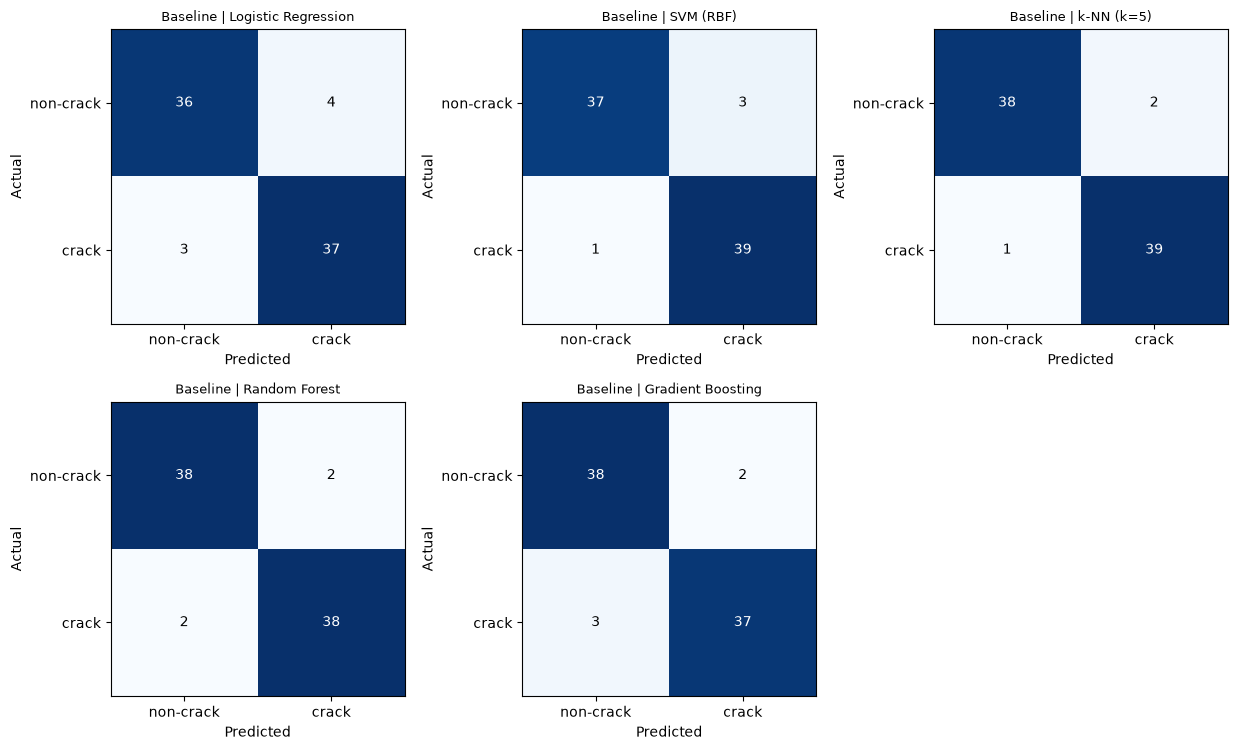

In [7]:
plot_confusion_matrices([(f"Baseline | {m}", cm) for (_, m), cm in cms_base.items()],
                        CLASS_NAMES_IMG, "image_confusion_matrices_baseline.png")

## A6. Reading the baseline results

Use the table above and the confusion matrices to answer, in your own words:
* Which model achieved the best F1 and recall, and how large is the gap to the others?
* Do cross-validated F1 (`cv_f1_mean`) and the test-set F1 agree? A large difference suggests the single split is unreliable.
* Which errors dominate in the confusion matrices: false positives or false negatives?

# Part C (image): Improve the representation

## C1. Richer, crack-specific features

The baseline features describe the whole image with global statistics. A crack is a thin, elongated, connected, dark structure, so each addition targets one of those properties:

| Addition | Justification |
|---|---|
| CLAHE + Gaussian blur before Canny | Corrects uneven lighting and suppresses grain, so fewer false edges come from the asphalt texture. |
| Median-based automatic Canny thresholds | Thresholds adapt to each image instead of one fixed pair for all images. |
| 4x4 grid of edge densities | Records where edges occur, so a localised crack differs from uniform texture. |
| Sobel gradient statistics | Measure edge strength, not only edge presence. |
| Black-hat morphology | Isolates thin dark structures, which is what a crack is. |
| Connected components on dilated edges | Cracks form long connected structures, whereas texture noise forms many small fragments. |
| Otsu dark ratio | A data-driven threshold replaces the arbitrary fixed value of 60. |

The cost is a larger feature vector (17 to 47 features) and a longer extraction time. Both are recorded so the trade-off can be quantified.

In [8]:
KERNEL_BH = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
KERNEL_DIL = np.ones((3, 3), np.uint8)


def improved_features(gray):
    feats = baseline_features(gray)
    prep = clahe_blur(gray)

    t_otsu, _ = cv2.threshold(prep, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    feats["otsu_threshold"] = float(t_otsu)
    feats["otsu_dark_ratio"] = float((prep < t_otsu).mean())

    edges = auto_canny(prep) > 0
    feats["canny_auto_edge_density"] = float(edges.mean())
    feats["canny_auto_edge_count"] = int(edges.sum())

    h, w = edges.shape
    cells = []
    for i in range(4):
        for j in range(4):
            d = float(edges[i * h // 4:(i + 1) * h // 4, j * w // 4:(j + 1) * w // 4].mean())
            feats[f"grid_edge_{i}{j}"] = d
            cells.append(d)
    feats["grid_edge_max"], feats["grid_edge_std"] = max(cells), float(np.std(cells))

    p = prep.astype(np.float32)
    mag = np.hypot(cv2.Sobel(p, cv2.CV_32F, 1, 0, ksize=3), cv2.Sobel(p, cv2.CV_32F, 0, 1, ksize=3))
    feats["sobel_mean"], feats["sobel_std"] = float(mag.mean()), float(mag.std())
    feats["sobel_p95"] = float(np.percentile(mag, 95))

    bh = cv2.morphologyEx(prep, cv2.MORPH_BLACKHAT, KERNEL_BH).astype(np.float32)
    feats["blackhat_mean"], feats["blackhat_p99"] = float(bh.mean()), float(np.percentile(bh, 99))
    feats["blackhat_ratio"] = float((bh > 15).mean())

    n, _, stats, _ = cv2.connectedComponentsWithStats(cv2.dilate(edges.astype(np.uint8), KERNEL_DIL), connectivity=8)
    feats["cc_count"] = int(n - 1)
    feats["largest_cc_ratio"] = float(stats[1:, cv2.CC_STAT_AREA].max() / gray.size) if n > 1 else 0.0
    return feats


t0 = time.perf_counter()
X_imp_df = pd.DataFrame([improved_features(g) for g in gray_images])
t_extract_imp = time.perf_counter() - t0
print(f"Improved: {X_imp_df.shape[1]} features, extraction time {t_extract_imp:.2f}s "
      f"(baseline: {X_base_df.shape[1]} features, {t_extract_base:.2f}s)")

tbl = X_imp_df.copy()
tbl.insert(0, "image", [p.name for p in paths]); tbl["label"] = y_img
tbl.to_csv(OUT_DIR / "image_features_improved.csv", index=False)

res_imp, cms_imp = run_image_experiment(X_imp_df, "Improved", t_extract_imp)
res_image = pd.concat([res_base, res_imp], ignore_index=True)
res_image.to_csv(OUT_DIR / "image_results.csv", index=False)
print(res_image.round(4).to_string(index=False))

Improved: 47 features, extraction time 5.06s (baseline: 17 features, 2.49s)
feature_set  n_features               model  accuracy  precision  recall     f1  cv_f1_mean  cv_f1_std  train_time_s  predict_time_s  feature_extraction_time_s
   Baseline          17 Logistic Regression    0.9125     0.9024   0.925 0.9136      0.9092     0.0243        0.0272          0.0013                     2.4940
   Baseline          17           SVM (RBF)    0.9500     0.9286   0.975 0.9512      0.9519     0.0221        0.0070          0.0018                     2.4940
   Baseline          17          k-NN (k=5)    0.9625     0.9512   0.975 0.9630      0.9514     0.0195        0.0014          3.4819                     2.4940
   Baseline          17       Random Forest    0.9500     0.9500   0.950 0.9500      0.9403     0.0203        0.5500          0.0603                     2.4940
   Baseline          17   Gradient Boosting    0.9375     0.9487   0.925 0.9367      0.9501     0.0235        0.3128        

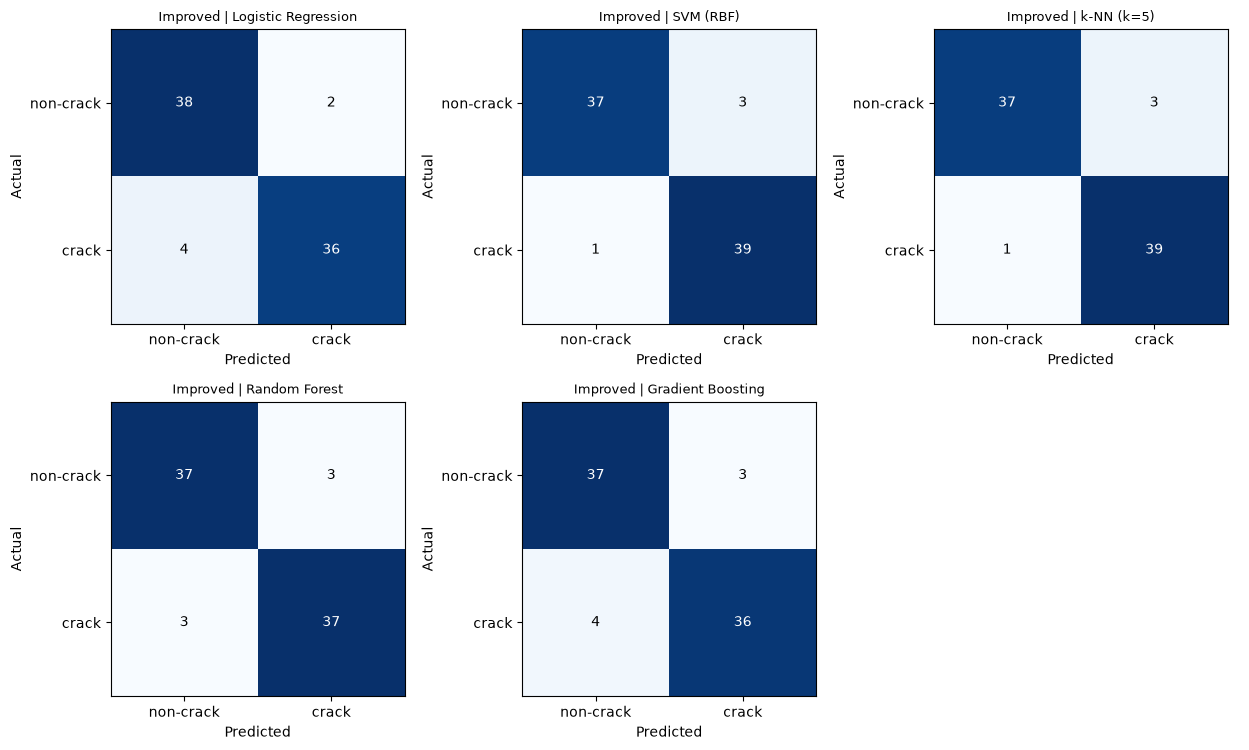

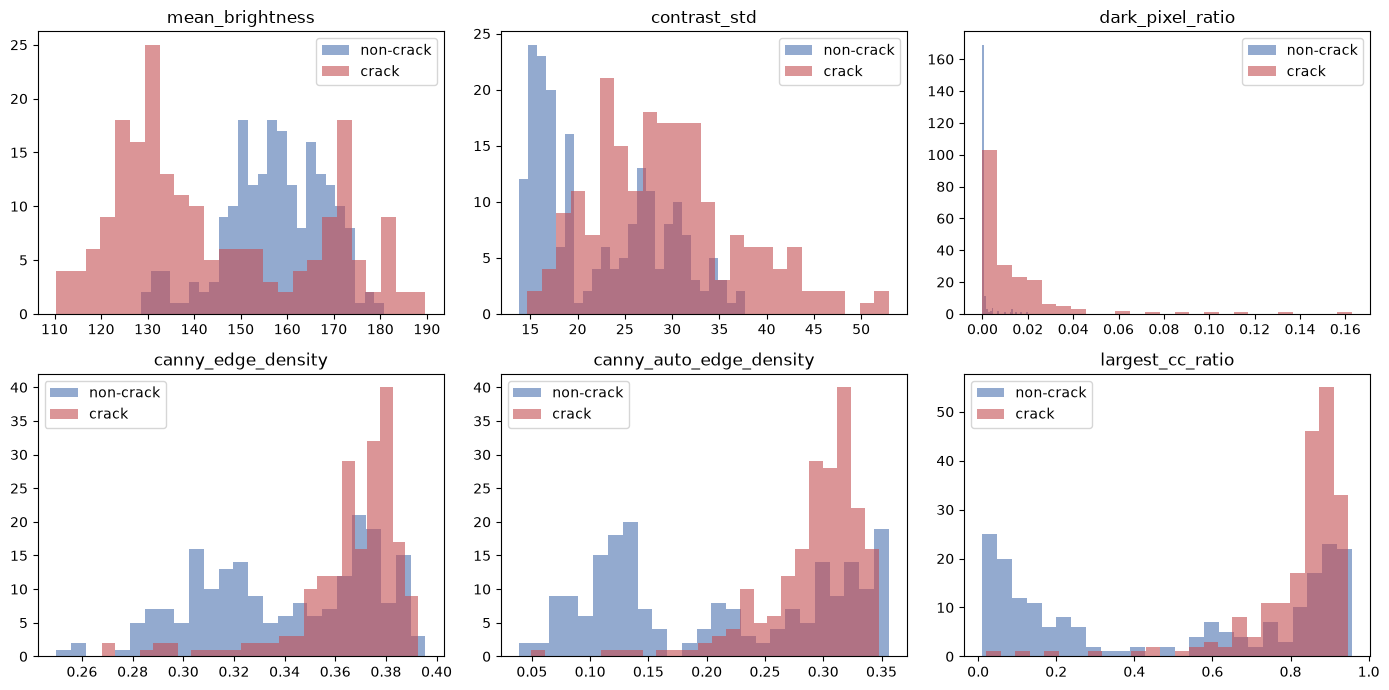

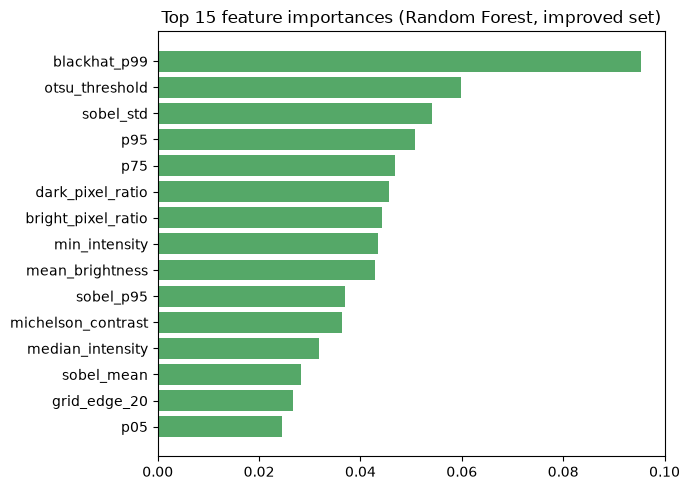

In [9]:
plot_confusion_matrices([(f"Improved | {m}", cm) for (_, m), cm in cms_imp.items()],
                        CLASS_NAMES_IMG, "image_confusion_matrices_improved.png")

# Feature distributions by class (evidence for the added features)
cols = ["mean_brightness", "contrast_std", "dark_pixel_ratio",
        "canny_edge_density", "canny_auto_edge_density", "largest_cc_ratio"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), cols):
    for c, color in ((0, "#4C72B0"), (1, "#C44E52")):
        ax.hist(X_imp_df.loc[y_img == c, col], bins=25, alpha=0.6, color=color, label=CLASS_NAMES_IMG[c])
    ax.set_title(col); ax.legend()
save_fig(fig, "feature_distributions_by_class.png")

# Random Forest feature importance on the improved feature set
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(X_imp_df.values[idx_tr], y_img[idx_tr])
imp = pd.Series(rf.feature_importances_, index=X_imp_df.columns).sort_values().tail(15)
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp.index, imp.values, color="#55A868"); ax.set_title("Top 15 feature importances (Random Forest, improved set)")
save_fig(fig, "image_feature_importance.png")

## C2. Baseline vs improved: summary and trade-off

Best image model per feature set:
feature_set      model  n_features  accuracy  precision  recall     f1  cv_f1_mean  train_time_s  predict_time_s  feature_extraction_time_s
   Baseline k-NN (k=5)          17    0.9625     0.9512   0.975 0.9630      0.9514        0.0014          3.4819                     2.4940
   Improved  SVM (RBF)          47    0.9500     0.9286   0.975 0.9512      0.9652        0.0053          0.0012                     5.0619


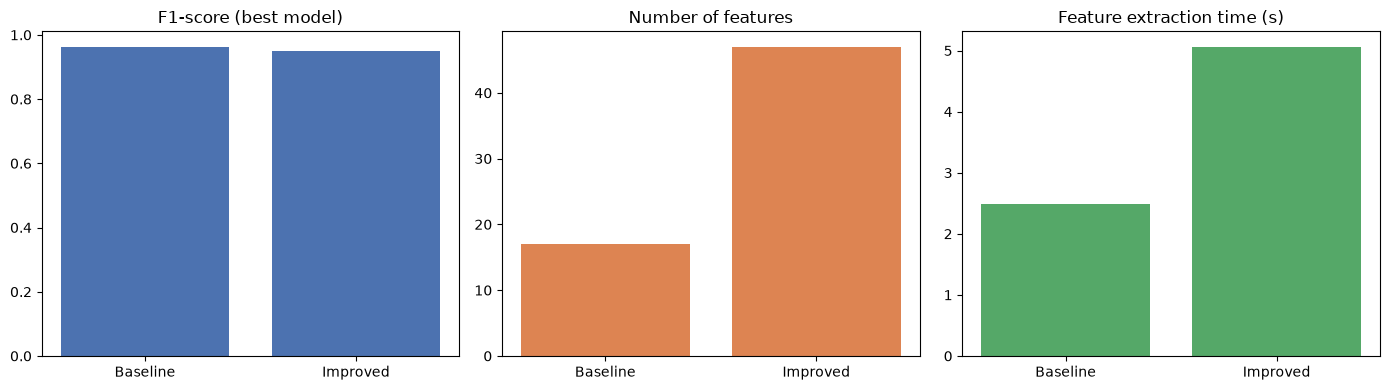


Saved files:
  results\figures\canny_edge_visualization.png
  results\figures\feature_distributions_by_class.png
  results\figures\image_confusion_matrices_baseline.png
  results\figures\image_confusion_matrices_improved.png
  results\figures\image_feature_importance.png
  results\figures\image_representation_comparison.png
  results\figures\sample_images.png
  results\figures\text_class_distribution.png
  results\figures\text_confusion_matrices.png
  results\figures\text_representation_comparison.png
  results\image_features_baseline.csv
  results\image_features_improved.csv
  results\image_metadata.csv
  results\image_results.csv
  results\text_results.csv


In [10]:
def best_per_group(df_, group_cols):
    return (df_.sort_values(["f1", "predict_time_s"], ascending=[False, True])
               .groupby(group_cols, sort=False).head(1))


best_img = best_per_group(res_image, ["feature_set"])
print("Best image model per feature set:")
print(best_img[["feature_set", "model", "n_features", "accuracy", "precision", "recall", "f1", "cv_f1_mean",
                "train_time_s", "predict_time_s", "feature_extraction_time_s"]].round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(best_img["feature_set"], best_img["f1"], color="#4C72B0"); axes[0].set_title("F1-score (best model)")
axes[1].bar(best_img["feature_set"], best_img["n_features"], color="#DD8452"); axes[1].set_title("Number of features")
axes[2].bar(best_img["feature_set"], best_img["feature_extraction_time_s"], color="#55A868"); axes[2].set_title("Feature extraction time (s)")
save_fig(fig, "image_representation_comparison.png")

print("\nSaved files:")
for f in sorted(OUT_DIR.rglob("*")):
    if f.is_file():
        print(" ", f)

## Observations and conclusions (complete after running on the real dataset)

Cite specific numbers from the tables and figures above.

1. **Best discriminating features.** Which features separate the classes most clearly (see `feature_distributions_by_class.png` and `image_feature_importance.png`)?
2. **Effect of the improved representation.** How did accuracy, precision, recall and F1 change from the baseline to the improved set? Did cross-validated F1 confirm the change?
3. **Cost of the improvement.** How much did the feature count and extraction time increase, and did training and prediction time change noticeably?
4. **Edge visualisation.** Compare the baseline and improved Canny outputs in `canny_edge_visualization.png`. Where did the fixed thresholds produce texture noise or miss faint cracks?
5. **Trade-off.** Was the gain in performance worth the extra dimensionality and computation? Which model offers the best balance of F1 and prediction time?
6. **Limitations.** Consider dataset size, the single train-test split, and the fact that hand-crafted global features cannot describe every crack shape or lighting condition.